In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [26]:
assets = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', '^NSEI', 'GOLDBEES.NS']

data = yf.download(assets, start="2022-01-01", end="2024-01-01")['Close']

/tmp/ipykernel_6377/2323987467.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start="2022-01-01", end="2024-01-01")['Close']
[*********************100%***********************]  5 of 5 completed


In [27]:
returns = data.pct_change().dropna()

In [28]:
weights = np.array([0.25, 0.20, 0.20, 0.20, 0.15])

portfolio_returns = returns.dot(weights)

In [29]:
VaR_95_hist = np.percentile(portfolio_returns, 5)
VaR_99_hist = np.percentile(portfolio_returns, 1)

In [30]:
mean = portfolio_returns.mean()
std = portfolio_returns.std()

VaR_95_param = stats.norm.ppf(0.05, mean, std)
VaR_99_param = stats.norm.ppf(0.01, mean, std)

In [31]:
simulations = 10000
simulated_returns = np.random.normal(mean, std, simulations)

VaR_95_mc = np.percentile(simulated_returns, 5)
VaR_99_mc = np.percentile(simulated_returns, 1)

In [32]:
CVaR_95 = portfolio_returns[portfolio_returns <= VaR_95_hist].mean()

In [33]:
rolling_VaR = portfolio_returns.rolling(window=100).quantile(0.05)

In [34]:
violations = portfolio_returns < VaR_95_hist
violation_rate = violations.mean()

In [35]:
stress_returns = portfolio_returns * 2
stress_VaR = np.percentile(stress_returns, 5)

In [36]:
print("HISTORICAL VAR")
print("VaR 95%:", VaR_95_hist)
print("VaR 99%:", VaR_99_hist)

print("\nPARAMETRIC VAR")
print("VaR 95%:", VaR_95_param)
print("VaR 99%:", VaR_99_param)

print("\nMONTE CARLO VAR")
print("VaR 95%:", VaR_95_mc)
print("VaR 99%:", VaR_99_mc)

print("\nEXPECTED SHORTFALL")
print("CVaR 95%:", CVaR_95)

print("\nBACKTESTING")
print("Violation Rate:", violation_rate)

print("\nSTRESS TEST")
print("Stress VaR (95%):", stress_VaR)

HISTORICAL VAR
VaR 95%: -0.012907215473575597
VaR 99%: -0.0177585908325954

PARAMETRIC VAR
VaR 95%: -0.011943447358747347
VaR 99%: -0.017057046993159176

MONTE CARLO VAR
VaR 95%: -0.012018078262384178
VaR 99%: -0.01705966776287953

EXPECTED SHORTFALL
CVaR 95%: -0.016270046644164822

BACKTESTING
Violation Rate: 0.0508130081300813

STRESS TEST
Stress VaR (95%): -0.025814430947151194


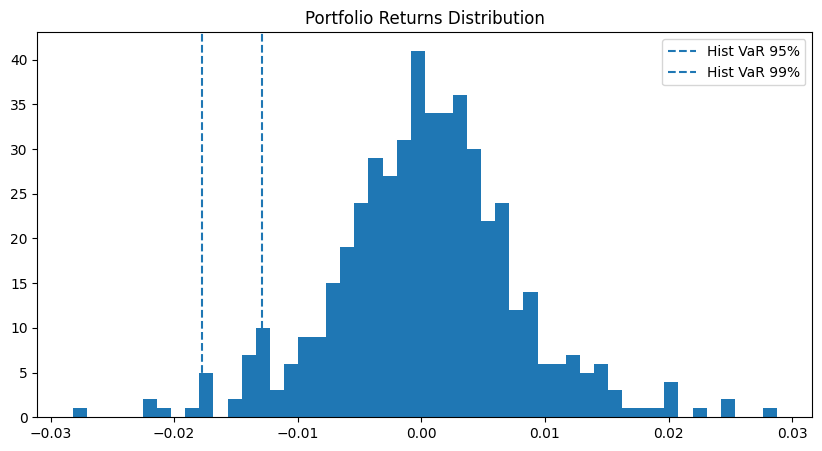

In [37]:
plt.figure(figsize=(10,5))
plt.hist(portfolio_returns, bins=50)
plt.axvline(VaR_95_hist, linestyle='dashed', label='Hist VaR 95%')
plt.axvline(VaR_99_hist, linestyle='dashed', label='Hist VaR 99%')
plt.legend()
plt.title("Portfolio Returns Distribution")
plt.show()


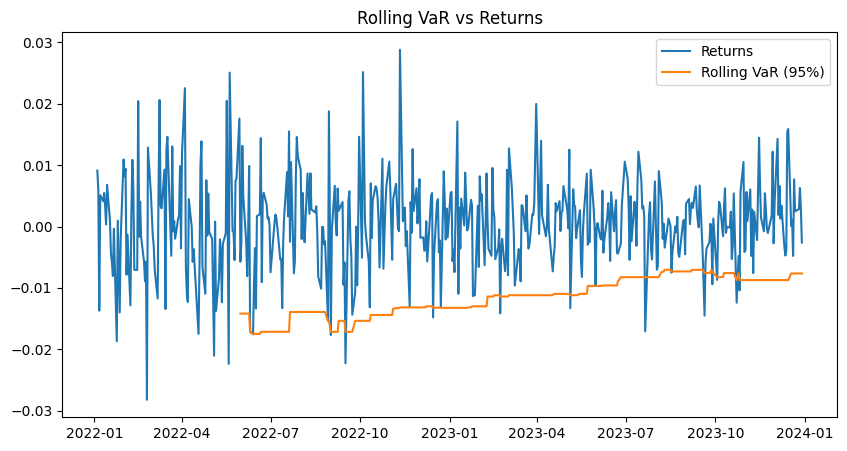

In [38]:
plt.figure(figsize=(10,5))
plt.plot(portfolio_returns, label='Returns')
plt.plot(rolling_VaR, label='Rolling VaR (95%)')
plt.legend()
plt.title("Rolling VaR vs Returns")
plt.show()

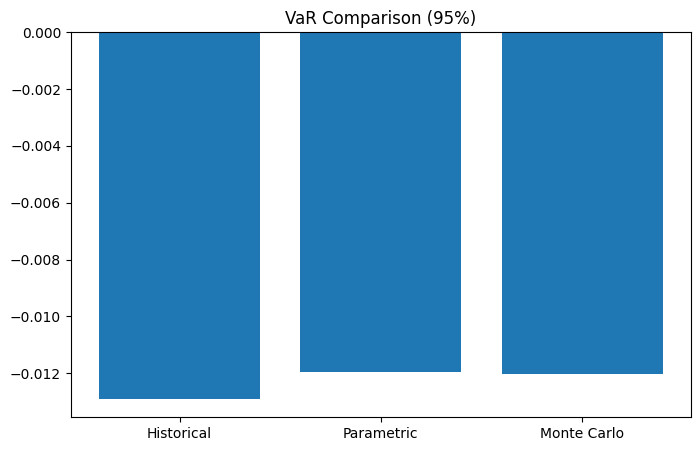

In [39]:
var_methods = ['Historical', 'Parametric', 'Monte Carlo']
var_values = [VaR_95_hist, VaR_95_param, VaR_95_mc]

plt.figure(figsize=(8,5))
plt.bar(var_methods, var_values)
plt.title("VaR Comparison (95%)")
plt.show()